In [114]:
import numpy as np
import json
import pickle
import os
from scipy.stats import norm
import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import tensorflow as tf
import matplotlib.pyplot as plt

In [86]:
class D4RL_Policy:
    """D4RL policy for evaluation."""

    def __init__(self, policy_file):
        with tf.io.gfile.GFile(os.path.join("gs://gresearch/deep-ope/d4rl", policy_file), 'rb') as f:
            weights = pickle.load(f)
#         weights = np.load(policy_file)
        self.fc0_w = weights['fc0/weight']
        self.fc0_b = weights['fc0/bias']
        self.fc1_w = weights['fc1/weight']
        self.fc1_b = weights['fc1/bias']
        self.fclast_w = weights['last_fc/weight']
        self.fclast_b = weights['last_fc/bias']
        self.fclast_w_logstd = weights['last_fc_log_std/weight']
        self.fclast_b_logstd = weights['last_fc_log_std/bias']
        self.nonlinearity = self.get_nonlinearity(weights['nonlinearity'])
        self.output_transformation = self.get_output_transformation(weights['output_distribution'])
        # self.action_dist = SquashedDiagGaussianDistribution(6) # For half cheetah

    def get_nonlinearity(self, nonlinearity_type):
        if nonlinearity_type == 'tanh':
            return np.tanh
        else:
            return self.relu

    @staticmethod
    def relu(x):
        return np.maximum(x, 0)

    def get_output_transformation(self, output_distribution):
        # print("output_distribution ", output_distribution)
        if output_distribution == 'tanh_gaussian':
            return np.tanh
        else:
            return self.identity
    @staticmethod
    def identity(x):
        return x
    def act(self, state, noise=0.01): # cannot be 0. -> std were discarded
        # state: (batch_size, state_dim)
        # action: (batch_size, action_dim)

        x = state.reshape(-1, 17)
        x = np.dot(x, self.fc0_w.T) + self.fc0_b
        x = self.nonlinearity(x)
        x = np.dot(x, self.fc1_w.T) + self.fc1_b
        x = self.nonlinearity(x)
        mean = np.dot(x, self.fclast_w.T) + self.fclast_b
        log_std = np.dot(x, self.fclast_w_logstd.T) + self.fclast_b_logstd

        action = self.output_transformation(mean + np.exp(log_std) * noise)
        return action, mean, log_std

    def inverse_tanh(self, x):
        # Clipping to avoid numerical issues
        return 0.5 * np.log((1 + np.clip(x, -0.999, 0.999)) / (1 - np.clip(x, -0.999, 0.999)))
    def log_prob(self, state, action):
        _, mean, log_std = self.act(state, noise=0.0)
        std = np.exp(np.clip(log_std, -20, 2))

        # Unsquash action
        pre_tanh_action = self.inverse_tanh(action)

        # Log PDF of Gaussian
        log_prob = norm.logpdf(pre_tanh_action, loc=mean, scale=std)
        log_prob = np.sum(log_prob)

        # Tanh correction (Jacobian of inverse)
        correction = np.sum(np.log(1 - np.tanh(pre_tanh_action) ** 2 + 1e-6))
        return log_prob - correction
    # def propensity_score(self, state, action):
    #     _, mean, log_std = self.act(state)
    #     # apply one more tanh after norm
    #     prob_density = np.tanh(norm.pdf(action, loc=mean, scale=np.exp(log_std)))
    #     prob_density = norm.pdf(action, loc=mean, scale=np.exp(log_std)) # need double check if it is correct
    #     # return self.action_dist.log_prob_from_params(mean, log_std)
    #     return np.prod(prob_density)
    #     # return np.max(np.prod(prob_density) + np.random.normal(loc=0, scale=0.2), 0)# Multiply over dimensions for multi-dimensional actions

In [87]:
pi_e = 10
pi_b = 9
ENV = "halfcheetah-medium-expert-v2"
rl_params = {
    'env_name': ENV,
}

with tf.io.gfile.GFile("./d4rl_policies.json", 'r') as f:
    policy_database = json.load(f)
policy_metadatas = [i for i in policy_database if
                    i['task.task_names'][0].find(rl_params['env_name'].split("-")[0] + "-") != -1]


target_policy = D4RL_Policy(policy_metadatas[pi_e]['policy_path'])
behavior_policy = D4RL_Policy(policy_metadatas[pi_b]['policy_path'])

gamma = 0.995

In [4]:
true_b_0 = pickle.load(open("./saved_trajectories/true_b.pkl", "rb"))
true_b_1 = pickle.load(open("./saved_trajectories/true_b_1.pkl", "rb"))
true_b_2 = pickle.load(open("./saved_trajectories/true_b_2.pkl", "rb"))
true_b_4 = pickle.load(open("./saved_trajectories/true_b_4.pkl", "rb"))
true_b_5 = pickle.load(open("./saved_trajectories/true_b_5.pkl", "rb"))
true_b_6 = pickle.load(open("./saved_trajectories/true_b_6.pkl", "rb"))
true_b_7 = pickle.load(open("./saved_trajectories/true_b_7.pkl", "rb"))
true_b_8 = pickle.load(open("./saved_trajectories/true_b_8.pkl", "rb"))
true_b_9 = pickle.load(open("./saved_trajectories/true_b_9.pkl", "rb"))
true_b_10 = pickle.load(open("./saved_trajectories/true_b_10.pkl", "rb"))
true_b_11 = pickle.load(open("./saved_trajectories/true_b_11.pkl", "rb"))
true_b_12 = pickle.load(open("./saved_trajectories/true_b_12.pkl", "rb"))
true_b_13 = pickle.load(open("./saved_trajectories/true_b_13.pkl", "rb"))
true_b_14 = pickle.load(open("./saved_trajectories/true_b_14.pkl", "rb"))

true_e = pickle.load(open("./saved_trajectories/true_e.pkl", "rb"))
true_e_s0 = pickle.load(open("./saved_trajectories/true_e_s0.pkl", "rb"))

dr_traj_0 = pickle.load(open("./saved_trajectories/matching_dr_ppi.pkl", "rb"))
dr_traj_1 = pickle.load(open("./saved_trajectories/matching_dr_ppi1.pkl", "rb"))
dr_traj_2 = pickle.load(open("./saved_trajectories/matching_dr_ppi2.pkl", "rb"))
dr_traj_4 = pickle.load(open("./saved_trajectories/matching_dr_ppi4.pkl", "rb"))
dr_traj_5 = pickle.load(open("./saved_trajectories/matching_dr_ppi5.pkl", "rb"))
dr_traj_6 = pickle.load(open("./saved_trajectories/matching_dr_ppi6.pkl", "rb"))
dr_traj_7 = pickle.load(open("./saved_trajectories/matching_dr_ppi7.pkl", "rb"))
dr_traj_8 = pickle.load(open("./saved_trajectories/matching_dr_ppi8.pkl", "rb"))
dr_traj_9 = pickle.load(open("./saved_trajectories/matching_dr_ppi9.pkl", "rb"))
dr_traj_10 = pickle.load(open("./saved_trajectories/matching_dr_ppi10.pkl", "rb"))
dr_traj_11 = pickle.load(open("./saved_trajectories/matching_dr_ppi11.pkl", "rb"))
dr_traj_12 = pickle.load(open("./saved_trajectories/matching_dr_ppi12.pkl", "rb"))
dr_traj_13 = pickle.load(open("./saved_trajectories/matching_dr_ppi13.pkl", "rb"))
dr_traj_14 = pickle.load(open("./saved_trajectories/matching_dr_ppi14.pkl", "rb"))

cp_traj_0 = pickle.load(open("./saved_trajectories/matching_cp_ppi.pkl", "rb"))
cp_traj_1 = pickle.load(open("./saved_trajectories/matching_cp_ppi1.pkl", "rb"))
cp_traj_2 = pickle.load(open("./saved_trajectories/matching_cp_ppi2.pkl", "rb"))
cp_traj_4 = pickle.load(open("./saved_trajectories/matching_cp_ppi4.pkl", "rb"))
cp_traj_5 = pickle.load(open("./saved_trajectories/matching_cp_ppi5.pkl", "rb"))
cp_traj_6 = pickle.load(open("./saved_trajectories/matching_cp_ppi6.pkl", "rb"))
cp_traj_7 = pickle.load(open("./saved_trajectories/matching_cp_ppi7.pkl", "rb"))
cp_traj_8 = pickle.load(open("./saved_trajectories/matching_cp_ppi8.pkl", "rb"))
cp_traj_9 = pickle.load(open("./saved_trajectories/matching_cp_ppi9.pkl", "rb"))
cp_traj_10 = pickle.load(open("./saved_trajectories/matching_cp_ppi10.pkl", "rb"))
cp_traj_11 = pickle.load(open("./saved_trajectories/matching_cp_ppi11.pkl", "rb"))
cp_traj_12 = pickle.load(open("./saved_trajectories/matching_cp_ppi12.pkl", "rb"))
cp_traj_13 = pickle.load(open("./saved_trajectories/matching_cp_ppi13.pkl", "rb"))
cp_traj_14 = pickle.load(open("./saved_trajectories/matching_cp_ppi14.pkl", "rb"))

In [5]:
# merge the behavior trajectories
true_b_0_states = true_b_0['states']
true_b_0_actions = true_b_0['actions']
true_b_0_rewards = true_b_0['rewards']
true_b_0_ep_returns = true_b_0['ep_returns']

true_b_1_states = true_b_1['states']
true_b_1_actions = true_b_1['actions']
true_b_1_rewards = true_b_1['rewards']
true_b_1_ep_returns = true_b_1['ep_returns']

true_b_2_states = true_b_2['states']
true_b_2_actions = true_b_2['actions']
true_b_2_rewards = true_b_2['rewards']
true_b_2_ep_returns = true_b_2['ep_returns']

true_b_4_states = true_b_4['states']
true_b_4_actions = true_b_4['actions']
true_b_4_rewards = true_b_4['rewards']
true_b_4_ep_returns = true_b_4['ep_returns']

true_b_5_states = true_b_5['states']
true_b_5_actions = true_b_5['actions']
true_b_5_rewards = true_b_5['rewards']
true_b_5_ep_returns = true_b_5['ep_returns']

true_b_6_states = true_b_6['states']
true_b_6_actions = true_b_6['actions']
true_b_6_rewards = true_b_6['rewards']
true_b_6_ep_returns = true_b_6['ep_returns']

true_b_7_states = true_b_7['states']
true_b_7_actions = true_b_7['actions']
true_b_7_rewards = true_b_7['rewards']
true_b_7_ep_returns = true_b_7['ep_returns']

true_b_8_states = true_b_8['states']
true_b_8_actions = true_b_8['actions']
true_b_8_rewards = true_b_8['rewards']
true_b_8_ep_returns = true_b_8['ep_returns']

true_b_9_states = true_b_9['states']
true_b_9_actions = true_b_9['actions']
true_b_9_rewards = true_b_9['rewards']
true_b_9_ep_returns = true_b_9['ep_returns']

true_b_10_states = true_b_10['states']
true_b_10_actions = true_b_10['actions']
true_b_10_rewards = true_b_10['rewards']
true_b_10_ep_returns = true_b_10['ep_returns']

true_b_11_states = true_b_11['states']
true_b_11_actions = true_b_11['actions']
true_b_11_rewards = true_b_11['rewards']
true_b_11_ep_returns = true_b_11['ep_returns']

true_b_12_states = true_b_12['states']
true_b_12_actions = true_b_12['actions']
true_b_12_rewards = true_b_12['rewards']
true_b_12_ep_returns = true_b_12['ep_returns']

true_b_13_states = true_b_13['states']
true_b_13_actions = true_b_13['actions']
true_b_13_rewards = true_b_13['rewards']
true_b_13_ep_returns = true_b_13['ep_returns']

true_b_14_states = true_b_14['states']
true_b_14_actions = true_b_14['actions']
true_b_14_rewards = true_b_14['rewards']
true_b_14_ep_returns = true_b_14['ep_returns']

true_b_states = np.concatenate((true_b_0_states, true_b_1_states, true_b_2_states, true_b_4_states, true_b_5_states, true_b_6_states, true_b_7_states, true_b_8_states, true_b_9_states, true_b_10_states, true_b_11_states, true_b_12_states, true_b_13_states, true_b_14_states), axis=0)
true_b_actions = np.concatenate((true_b_0_actions, true_b_1_actions, true_b_2_actions, true_b_4_actions, true_b_5_actions, true_b_6_actions, true_b_7_actions, true_b_8_actions, true_b_9_actions, true_b_10_actions, true_b_11_actions, true_b_12_actions, true_b_13_actions, true_b_14_actions), axis=0)
true_b_rewards = np.concatenate((true_b_0_rewards, true_b_1_rewards, true_b_2_rewards, true_b_4_rewards, true_b_5_rewards, true_b_6_rewards, true_b_7_rewards, true_b_8_rewards, true_b_9_rewards, true_b_10_rewards, true_b_11_rewards, true_b_12_rewards, true_b_13_rewards, true_b_14_rewards), axis=0)
true_b_ep_returns = np.concatenate((true_b_0_ep_returns, true_b_1_ep_returns, true_b_2_ep_returns, true_b_4_ep_returns, true_b_5_ep_returns, true_b_6_ep_returns, true_b_7_ep_returns, true_b_8_ep_returns, true_b_9_ep_returns, true_b_10_ep_returns, true_b_11_ep_returns, true_b_12_ep_returns, true_b_13_ep_returns, true_b_14_ep_returns), axis=0)


true_b = {
    'states': true_b_states,
    'actions': true_b_actions,
    'rewards': true_b_rewards,
    'ep_returns': true_b_ep_returns
}

In [7]:
r_true_b = true_b['ep_returns']
print(np.mean(r_true_b), len(r_true_b))

r_true_e = true_e['ep_returns']
print(np.mean(r_true_e), len(r_true_e))

r_true_e_s0 = true_e_s0['ep_returns']
print(np.mean(r_true_e_s0), len(r_true_e_s0))

1813.4442011141405 11300
1975.7453964793044 1000
1990.392362687519 1000


In [308]:
# log_w_IS = []
# for i in range(len(true_b_actions)):
#     log_w = 0
#     for t in range(len(true_b_actions[i])):
#         log_rho_e = target_policy.log_prob(true_b_states[i][t], true_b_actions[i][t])
#         log_rho_b = behavior_policy.log_prob(true_b_states[i][t], true_b_actions[i][t])
#         log_rho = log_rho_e - log_rho_b
#         log_w += log_rho
#     log_w_IS.append(log_w)

# # save the log weights
# with open("./log_w_IS.pkl", "wb") as f:
#     pickle.dump(log_w_IS, f)

In [9]:
log_w_IS = pickle.load(open("./log_w_IS.pkl", "rb"))

In [ ]:
# log_w_PDIS = np.zeros((len(true_b_actions), len(true_b_actions[0])))
# for i in range(len(true_b_actions)):
#     log_w = 0
#     for t in range(len(true_b_actions[i])):
#         log_rho_e = target_policy.log_prob(true_b_states[i][t], true_b_actions[i][t])
#         log_rho_b = behavior_policy.log_prob(true_b_states[i][t], true_b_actions[i][t])
#         log_rho = log_rho_e - log_rho_b
#         log_w += log_rho
#         log_w_PDIS[i][t] = log_w

# # save the log weights
# with open("./log_w_PDIS.pkl", "wb") as f:
#     pickle.dump(log_w_PDIS, f)

In [10]:
log_w_PDIS = pickle.load(open("./log_w_PDIS.pkl", "rb"))

In [11]:
# OPE starts from here
alpha = 0.05
z = norm.ppf(1 - alpha / 2)

In [120]:
# MB
first_term_dr_ppi = pickle.load(open("./saved_trajectories/first_term_dr_ppi.pkl", "rb"))
V_MB = np.mean(first_term_dr_ppi['ep_returns'])
print("V_MB: ", V_MB)

V_MB:  1423.5662131484473


In [12]:
# IS CLT
weights = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    log_w = log_w_IS[i]
    log_w = np.clip(log_w, a_min=-10, a_max=3.6)
    w = np.exp(log_w)
    weights[i] = w

V_IS = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    V_IS[i] = weights[i] * true_b_ep_returns[i]
V_IS_mean = np.mean(V_IS)
V_IS_var = np.var(V_IS)
V_IS_lb = np.mean(V_IS) - z * np.sqrt(V_IS_var / len(V_IS))
V_IS_ub = np.mean(V_IS) + z * np.sqrt(V_IS_var / len(V_IS))
print("V_IS mean: ", V_IS_mean)
print("V_IS var: ", V_IS_var)
print("V_IS lb: ", V_IS_lb)
print("V_IS ub: ", V_IS_ub)

V_IS mean:  2692.22457890597
V_IS var:  129105270.18212359
V_IS lb:  2482.726109327591
V_IS ub:  2901.7230484843485


In [13]:
# IS Bootstrap
bootstrap_samples = 100
V_IS_bootstrap = np.zeros(bootstrap_samples)
for i in range(bootstrap_samples):
    idx = np.random.randint(0, len(true_b_actions), len(true_b_actions))
    V_IS_bootstrap[i] = np.mean(V_IS[idx])
V_IS_bootstrap_mean = np.mean(V_IS_bootstrap)
# get the alpha quantile and (1-alpha) quantile
V_IS_bootstrap_alpha = np.quantile(V_IS_bootstrap, alpha/2)
V_IS_bootstrap_1_alpha = np.quantile(V_IS_bootstrap, 1 - alpha/2)
print('V_IS_bootstrap:', V_IS_bootstrap_mean)
print('V_IS_bootstrap_lb:', V_IS_bootstrap_alpha)
print('V_IS_bootstrap_1_ub:', V_IS_bootstrap_1_alpha)

V_IS_bootstrap: 2691.637619403262
V_IS_bootstrap_lb: 2500.5126684256124
V_IS_bootstrap_1_ub: 2905.574571264913


In [16]:
# devide the b_trajs into 2 parts
true_b_states_train = true_b_states[:int(len(true_b_states) * 0.5)]
true_b_actions_train = true_b_actions[:int(len(true_b_actions) * 0.5)]
true_b_rewards_train = true_b_rewards[:int(len(true_b_rewards) * 0.5)]
true_b_ep_returns_train = true_b_ep_returns[:int(len(true_b_ep_returns) * 0.5)]

true_b_states_cal = true_b_states[int(len(true_b_states) * 0.5):]
true_b_actions_cal = true_b_actions[int(len(true_b_actions) * 0.5):]
true_b_rewards_cal = true_b_rewards[int(len(true_b_rewards) * 0.5):]
true_b_ep_returns_cal = true_b_ep_returns[int(len(true_b_ep_returns) * 0.5):]

In [95]:
# convert to batch data
def convert_to_batch_data(trajectories, actions, rewards):
    batch_data = []
    for traj, action, reward in zip(trajectories, actions, rewards):
        for t in range(len(traj)-1):
            s = traj[t]
            a = action[t]
            r = reward[t]
            s_next = traj[t+1]
            batch_data.append((s, a, r, s_next))
    return batch_data
batch_data = convert_to_batch_data(true_b_states_train, true_b_actions_train, true_b_rewards_train)

state_dim = 17
action_dim = 6

In [127]:
# DR CLT

# train a DQN using the batch data
class DQN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, s, a):
        x = torch.cat((s, a), dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
Q = DQN(input_dim=state_dim + action_dim, hidden_dim=16, output_dim=1)

In [130]:
optimizer = optim.Adam(Q.parameters(), lr=0.001)
criterion = nn.MSELoss()
num_epochs = 100
batch_size = 4096
for epoch in range(num_epochs):
    np.random.shuffle(batch_data)
    for i in range(0, len(batch_data), batch_size):
        batch = batch_data[i:i + batch_size]
        s = torch.tensor([b[0] for b in batch], dtype=torch.float32)
        a = torch.tensor([b[1] for b in batch], dtype=torch.float32)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        s1 = torch.tensor([b[3] for b in batch], dtype=torch.float32)
        # print(s.shape, a.shape, r.shape, s1.shape)
        q_value = Q(s, a)
        # print(q_value.shape)
        V_pi_e = 0

        a_e, _, _ = target_policy.act(s1.numpy()) # very deterministic
        a_e = torch.tensor(a_e, dtype=torch.float32)
        q_value_e = Q(s1, a_e)
        V_pi_e = q_value_e
        
        target_q_value = r.unsqueeze(1) + gamma * V_pi_e
        loss = criterion(q_value, target_q_value)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 1 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [0/100], Loss: 56.5647
Epoch [1/100], Loss: 51.0824
Epoch [2/100], Loss: 45.1745
Epoch [3/100], Loss: 44.1257
Epoch [4/100], Loss: 42.7613
Epoch [5/100], Loss: 39.7645
Epoch [6/100], Loss: 38.5643
Epoch [7/100], Loss: 37.6492
Epoch [8/100], Loss: 39.4187
Epoch [9/100], Loss: 39.0711
Epoch [10/100], Loss: 33.7240
Epoch [11/100], Loss: 34.7648
Epoch [12/100], Loss: 34.2052
Epoch [13/100], Loss: 35.7403
Epoch [14/100], Loss: 35.8530
Epoch [15/100], Loss: 32.5029
Epoch [16/100], Loss: 34.4158
Epoch [17/100], Loss: 31.7804
Epoch [18/100], Loss: 33.1747
Epoch [19/100], Loss: 32.9088
Epoch [20/100], Loss: 32.1829
Epoch [21/100], Loss: 31.4040
Epoch [22/100], Loss: 30.5402
Epoch [23/100], Loss: 30.5135
Epoch [24/100], Loss: 30.5707
Epoch [25/100], Loss: 27.5920
Epoch [26/100], Loss: 27.5442
Epoch [27/100], Loss: 27.7667
Epoch [28/100], Loss: 25.2451
Epoch [29/100], Loss: 25.4941
Epoch [30/100], Loss: 21.9432
Epoch [31/100], Loss: 21.9795
Epoch [32/100], Loss: 21.6141
Epoch [33/100], Loss

In [ ]:
V_DR_step = np.zeros(len(true_b_actions_cal))
for i in range(len(true_b_actions_cal)):
    v = 0
    for t in range(len(true_b_actions_cal[i])):
        s = true_b_states_cal[i][t]
        a = true_b_actions_cal[i][t]
        r = true_b_rewards_cal[i][t]
        
        log_w = target_policy.log_prob(s, a) - behavior_policy.log_prob(s, a)
        clip_log_w = np.clip(log_w, a_min=-10, a_max=3.6)
        w = np.exp(clip_log_w)

        s = torch.tensor(s, dtype=torch.float32).reshape(1, -1)
        a = torch.tensor(a, dtype=torch.float32).reshape(1, -1)
        Q_s_a = float(Q(s, a).detach().numpy())
        
        a_e, _, _ = target_policy.act(s.numpy())
        a_e = torch.tensor(a_e, dtype=torch.float32).reshape(1, -1)
        V_s = float(Q(s, a_e).detach().numpy())

        v = V_s + w * (r + gamma * v - Q_s_a)
    V_DR_step[i] = v
    print(i, v)

In [136]:
# calculate the average of V_DR
# filter the non-inf values
V_DR_step = V_DR_step[~np.isinf(V_DR_step)]
V_DR_step_mean = np.mean(V_DR_step)
V_DR_step_var = np.var(V_DR_step)
V_DR_step_lb = V_DR_step_mean - z * np.sqrt(V_DR_step_var / len(V_DR_step))
V_DR_step_ub = V_DR_step_mean + z * np.sqrt(V_DR_step_var / len(V_DR_step))
print('V_DR:', V_DR_step_mean)
print('V_DR_LB:', V_DR_step_lb)
print('V_DR_UB:', V_DR_step_ub)

V_DR: -7.525378399889739e+282
V_DR_LB: -inf
V_DR_UB: inf


/opt/anaconda3/envs/sepsis/lib/python3.9/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


In [468]:
# WIS
normalized_weights = weights / np.sum(weights)
V_WIS = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    V_WIS[i] = normalized_weights[i] * true_b_ep_returns[i]
V_WIS_mean = np.mean(V_WIS)
V_WIS_var = np.var(V_WIS)
V_WIS_lb = np.mean(V_WIS) - z * np.sqrt(V_WIS_var / len(V_WIS))
V_WIS_ub = np.mean(V_WIS) + z * np.sqrt(V_WIS_var / len(V_WIS))
print("V_WIS mean: ", V_WIS_mean)
print("V_WIS var: ", V_WIS_var)
print("V_WIS lb: ", V_WIS_lb)
print("V_WIS ub: ", V_WIS_ub)


V_WIS mean:  0.1205901606994421
V_WIS var:  0.25902706757422994
V_WIS lb:  0.11120630234279263
V_WIS ub:  0.12997401905609157


In [ ]:
# PDIS
reweighted_values = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    v = 0
    for t in range(len(true_b_actions[i])):
        log_w = log_w_PDIS[i][t]
        clip_log_w = np.clip(log_w, a_min=-10, a_max=3.6)
        v += true_b_rewards[i][t] * (gamma ** t) * np.exp(clip_log_w)
    reweighted_values[i] = v

V_PDIS = reweighted_values
V_PDIS_mean = np.mean(V_PDIS)
V_PDIS_var = np.var(V_PDIS)
V_PDIS_lb = np.mean(V_PDIS) - z * np.sqrt(V_PDIS_var / len(V_PDIS))
V_PDIS_ub = np.mean(V_PDIS) + z * np.sqrt(V_PDIS_var / len(V_PDIS))
print("V_PDIS mean: ", V_PDIS_mean)
print("V_PDIS var: ", V_PDIS_var)
print("V_PDIS lb: ", V_PDIS_lb)
print("V_PDIS ub: ", V_PDIS_ub)

V_PDIS mean:  1955.3101538972396
V_PDIS var:  58431745.845988296
V_PDIS lb:  1814.3704675914128
V_PDIS ub:  2096.2498402030665


In [110]:
# load the agumented data
learned_b_1 = pickle.load(open("./saved_trajectories/learned_b_1.pkl", "rb"))
learned_b_2 = pickle.load(open("./saved_trajectories/learned_b_2.pkl", "rb"))
learned_b_3 = pickle.load(open("./saved_trajectories/learned_b_3.pkl", "rb"))
learned_b_4 = pickle.load(open("./saved_trajectories/learned_b_4.pkl", "rb"))
learned_b_5 = pickle.load(open("./saved_trajectories/learned_b_5.pkl", "rb"))
learned_b_6 = pickle.load(open("./saved_trajectories/learned_b_6.pkl", "rb"))
learned_b_7 = pickle.load(open("./saved_trajectories/learned_b_7.pkl", "rb"))
learned_b_8 = pickle.load(open("./saved_trajectories/learned_b_8.pkl", "rb"))
learned_b_9 = pickle.load(open("./saved_trajectories/learned_b_9.pkl", "rb"))
learned_b_10 = pickle.load(open("./saved_trajectories/learned_b_10.pkl", "rb"))

# merge the learned trajectories
learned_b_1_states = learned_b_1['states']
learned_b_1_actions = learned_b_1['actions']
learned_b_1_rewards = learned_b_1['rewards']
learned_b_1_ep_returns = learned_b_1['ep_returns']

learned_b_2_states = learned_b_2['states']
learned_b_2_actions = learned_b_2['actions']
learned_b_2_rewards = learned_b_2['rewards']
learned_b_2_ep_returns = learned_b_2['ep_returns']

learned_b_3_states = learned_b_3['states']
learned_b_3_actions = learned_b_3['actions']
learned_b_3_rewards = learned_b_3['rewards']
learned_b_3_ep_returns = learned_b_3['ep_returns']

learned_b_4_states = learned_b_4['states']
learned_b_4_actions = learned_b_4['actions']
learned_b_4_rewards = learned_b_4['rewards']
learned_b_4_ep_returns = learned_b_4['ep_returns']

learned_b_5_states = learned_b_5['states']
learned_b_5_actions = learned_b_5['actions']
learned_b_5_rewards = learned_b_5['rewards']
learned_b_5_ep_returns = learned_b_5['ep_returns']

learned_b_6_states = learned_b_6['states']
learned_b_6_actions = learned_b_6['actions']
learned_b_6_rewards = learned_b_6['rewards']
learned_b_6_ep_returns = learned_b_6['ep_returns']

learned_b_7_states = learned_b_7['states']
learned_b_7_actions = learned_b_7['actions']
learned_b_7_rewards = learned_b_7['rewards']
learned_b_7_ep_returns = learned_b_7['ep_returns']

learned_b_8_states = learned_b_8['states']
learned_b_8_actions = learned_b_8['actions']
learned_b_8_rewards = learned_b_8['rewards']
learned_b_8_ep_returns = learned_b_8['ep_returns']

learned_b_9_states = learned_b_9['states']
learned_b_9_actions = learned_b_9['actions']
learned_b_9_rewards = learned_b_9['rewards']
learned_b_9_ep_returns = learned_b_9['ep_returns']

learned_b_10_states = learned_b_10['states']
learned_b_10_actions = learned_b_10['actions']
learned_b_10_rewards = learned_b_10['rewards']
learned_b_10_ep_returns = learned_b_10['ep_returns']

learned_b_states = np.concatenate((learned_b_1_states, learned_b_2_states, learned_b_3_states, learned_b_4_states, learned_b_5_states, learned_b_6_states, learned_b_7_states, learned_b_8_states, learned_b_9_states, learned_b_10_states), axis=0)
learned_b_actions = np.concatenate((learned_b_1_actions, learned_b_2_actions, learned_b_3_actions, learned_b_4_actions, learned_b_5_actions, learned_b_6_actions, learned_b_7_actions, learned_b_8_actions, learned_b_9_actions, learned_b_10_actions), axis=0)
learned_b_rewards = np.concatenate((learned_b_1_rewards, learned_b_2_rewards, learned_b_3_rewards, learned_b_4_rewards, learned_b_5_rewards, learned_b_6_rewards, learned_b_7_rewards, learned_b_8_rewards, learned_b_9_rewards, learned_b_10_rewards), axis=0)
learned_b_ep_returns = np.concatenate((learned_b_1_ep_returns, learned_b_2_ep_returns, learned_b_3_ep_returns, learned_b_4_ep_returns, learned_b_5_ep_returns, learned_b_6_ep_returns, learned_b_7_ep_returns, learned_b_8_ep_returns, learned_b_9_ep_returns, learned_b_10_ep_returns), axis=0)

learned_b = {
    'states': learned_b_states,
    'actions': learned_b_actions,
    'rewards': learned_b_rewards,
    'ep_returns': learned_b_ep_returns
}

In [111]:
whole_b_states = np.concatenate((true_b_states, learned_b_states), axis=0)
whole_b_actions = np.concatenate((true_b_actions, learned_b_actions), axis=0)
whole_b_rewards = np.concatenate((true_b_rewards, learned_b_rewards), axis=0)
whole_b_ep_returns = np.concatenate((true_b_ep_returns, learned_b_ep_returns), axis=0)

whole_b = {
    'states': whole_b_states,
    'actions': whole_b_actions,
    'rewards': whole_b_rewards,
    'ep_returns': whole_b_ep_returns
}

In [113]:
# learned_log_w_IS = []
# for i in range(len(learned_b_actions)):
#     log_w = 0
#     for t in range(len(learned_b_actions[i])):
#         log_rho_e = target_policy.log_prob(learned_b_states[i][t], learned_b_actions[i][t])
#         log_rho_b = behavior_policy.log_prob(learned_b_states[i][t], learned_b_actions[i][t])
#         log_rho = log_rho_e - log_rho_b
#         log_w += log_rho
#     learned_log_w_IS.append(log_w)

# # save the log weights
# with open("./learned_log_w_IS.pkl", "wb") as f:
#     pickle.dump(learned_log_w_IS, f)

In [115]:
learned_log_w_IS = pickle.load(open("./learned_log_w_IS.pkl", "rb"))

In [117]:
# augment IS CLT
weights = np.zeros(len(whole_b_actions))
for i in range(len(true_b_actions)):
    log_w = log_w_IS[i]
    log_w = np.clip(log_w, a_min=-10, a_max=3.6)
    w = np.exp(log_w)
    weights[i] = w
for i in range(len(learned_b_actions)):
    log_w = learned_log_w_IS[i]
    log_w = np.clip(log_w, a_min=-10, a_max=3.6)
    w = np.exp(log_w)
    weights[i + len(true_b_actions)] = w

aug_V_IS = np.zeros(len(whole_b_actions))
for i in range(len(whole_b_actions)):
    aug_V_IS[i] = weights[i] * whole_b_ep_returns[i]
aug_V_IS_mean = np.mean(aug_V_IS)
aug_V_IS_var = np.var(aug_V_IS)
aug_V_IS_lb = np.mean(aug_V_IS) - z * np.sqrt(aug_V_IS_var / len(aug_V_IS))
aug_V_IS_ub = np.mean(aug_V_IS) + z * np.sqrt(aug_V_IS_var / len(aug_V_IS))
print("aug_V_IS mean: ", aug_V_IS_mean)
print("aug_V_IS var: ", aug_V_IS_var)
print("aug_V_IS lb: ", aug_V_IS_lb)
print("aug_V_IS ub: ", aug_V_IS_ub)


aug_V_IS mean:  1428.2984615728876
aug_V_IS var:  70297652.7097077
aug_V_IS lb:  1315.700973697451
aug_V_IS ub:  1540.8959494483242


In [118]:
# augment IS Bootstrap
aug_bootstrap_samples = 100
aug_V_IS_bootstrap = np.zeros(aug_bootstrap_samples)
for i in range(aug_bootstrap_samples):
    idx = np.random.randint(0, len(whole_b_actions), len(whole_b_actions))
    aug_V_IS_bootstrap[i] = np.mean(aug_V_IS[idx])
aug_V_IS_bootstrap_mean = np.mean(aug_V_IS_bootstrap)
# get the alpha quantile and (1-alpha) quantile
aug_V_IS_bootstrap_alpha = np.quantile(aug_V_IS_bootstrap, alpha/2)
aug_V_IS_bootstrap_1_alpha = np.quantile(aug_V_IS_bootstrap, 1 - alpha/2)
print('aug_V_IS_bootstrap:', aug_V_IS_bootstrap_mean)
print('aug_V_IS_bootstrap_lb:', aug_V_IS_bootstrap_alpha)
print('aug_V_IS_bootstrap_1_ub:', aug_V_IS_bootstrap_1_alpha)

aug_V_IS_bootstrap: 1431.9645479625945
aug_V_IS_bootstrap_lb: 1342.2347026643017
aug_V_IS_bootstrap_1_ub: 1533.9490758419092


In [ ]:
# augment DR CLT


In [ ]:
# DR_PPI
# merge the dr_trajectories
dr_traj_0_ep_returns = [dr_traj_0[i]['ep_returns'][0] for i in range(100)]
dr_traj_1_ep_returns = [dr_traj_1[i]['ep_returns'][0] for i in range(100)]
dr_traj_2_ep_returns = [dr_traj_2[i]['ep_returns'][0] for i in range(100)]
dr_traj_4_ep_returns = dr_traj_4['ep_returns']
dr_traj_5_ep_returns = dr_traj_5['ep_returns']
dr_traj_6_ep_returns = dr_traj_6['ep_returns']
dr_traj_7_ep_returns = dr_traj_7['ep_returns']
dr_traj_8_ep_returns = dr_traj_8['ep_returns']
dr_traj_9_ep_returns = dr_traj_9['ep_returns']
dr_traj_10_ep_returns = dr_traj_10['ep_returns']
dr_traj_11_ep_returns = dr_traj_11['ep_returns']
dr_traj_12_ep_returns = dr_traj_12['ep_returns']
dr_traj_13_ep_returns = dr_traj_13['ep_returns']
dr_traj_14_ep_returns = dr_traj_14['ep_returns']

dr_trajs_ep_returns = np.concatenate((dr_traj_0_ep_returns, dr_traj_1_ep_returns, dr_traj_2_ep_returns, dr_traj_4_ep_returns, dr_traj_5_ep_returns, dr_traj_6_ep_returns, dr_traj_7_ep_returns, dr_traj_8_ep_returns, dr_traj_9_ep_returns, dr_traj_10_ep_returns, dr_traj_11_ep_returns, dr_traj_12_ep_returns, dr_traj_13_ep_returns, dr_traj_14_ep_returns), axis=0)

In [121]:
#IS
weights = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    log_w = log_w_IS[i]
    log_w = np.clip(log_w, a_min=-10, a_max=3.6)
    w = np.exp(log_w)
    weights[i] = w

E_diff_rewards_IS = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    diff = weights[i]*true_b_ep_returns[i] - dr_trajs_ep_returns[i]
    E_diff_rewards_IS[i] = diff

E_diff_rewards_IS_mean = np.mean(E_diff_rewards_IS)
sigma_b2_IS = np.var(E_diff_rewards_IS)

# WIS
normalized_weights = weights / np.sum(weights)
E_diff_rewards_WIS = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    diff = normalized_weights[i]*true_b_ep_returns[i] - dr_trajs_ep_returns[i]
    E_diff_rewards_WIS[i] = diff

E_diff_rewards_WIS_mean = np.mean(E_diff_rewards_WIS)
sigma_b2_WIS = np.var(E_diff_rewards_WIS)

# PDIS
reweighted_values = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    v = 0
    for t in range(len(true_b_actions[i])):
        log_w = log_w_PDIS[i][t]
        clip_log_w = np.clip(log_w, a_min=-10, a_max=3.6)
        v += true_b_rewards[i][t] * (gamma ** t) * np.exp(clip_log_w)
    reweighted_values[i] = v

E_diff_rewards_PDIS = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    diff = reweighted_values[i] - dr_trajs_ep_returns[i]
    E_diff_rewards_PDIS[i] = diff

E_diff_rewards_PDIS_mean = np.mean(E_diff_rewards_PDIS)
sigma_b2_PDIS = np.var(E_diff_rewards_PDIS)



In [122]:
E_diff_rewards_IS_mean, sigma_b2_IS

(np.float64(1275.0433324651653), np.float64(129065926.1715902))

In [123]:
E_diff_rewards_PDIS_mean, sigma_b2_PDIS

(np.float64(538.128907456435), np.float64(58404220.93800996))

In [124]:
dr_ppi_e = pickle.load(open("./saved_trajectories/first_term_dr_ppi.pkl", "rb"))
first_term_dr_ppi = np.mean(dr_ppi_e['ep_returns'])
sigma_f2 = np.var(dr_ppi_e['ep_returns'])

In [125]:
V_DRPPI_IS_mean = first_term_dr_ppi + E_diff_rewards_IS_mean
V_DRPPI_IS_var = sigma_f2 / len(dr_ppi_e['ep_returns']) + sigma_b2_IS / len(true_b_actions)
V_DRPPI_IS_lb = V_DRPPI_IS_mean - z * np.sqrt(V_DRPPI_IS_var)
V_DRPPI_IS_ub = V_DRPPI_IS_mean + z * np.sqrt(V_DRPPI_IS_var)
print("V_DRPPI_IS_mean: ", V_DRPPI_IS_mean)
print("V_DRPPI_IS_var: ", V_DRPPI_IS_var)
print("V_DRPPI_IS_lb: ", V_DRPPI_IS_lb)
print("V_DRPPI_IS_ub: ", V_DRPPI_IS_ub)

V_DRPPI_WIS_mean = first_term_dr_ppi + E_diff_rewards_WIS_mean
V_DRPPI_WIS_var = sigma_f2 / len(dr_ppi_e['ep_returns']) + sigma_b2_WIS / len(true_b_actions)
V_DRPPI_WIS_lb = V_DRPPI_WIS_mean - z * np.sqrt(V_DRPPI_WIS_var)
V_DRPPI_WIS_ub = V_DRPPI_WIS_mean + z * np.sqrt(V_DRPPI_WIS_var)
print("V_DRPPI_WIS_mean: ", V_DRPPI_WIS_mean)
print("V_DRPPI_WIS_var: ", V_DRPPI_WIS_var)
print("V_DRPPI_WIS_lb: ", V_DRPPI_WIS_lb)
print("V_DRPPI_WIS_ub: ", V_DRPPI_WIS_ub)

V_DRPPI_PDIS_mean = first_term_dr_ppi + E_diff_rewards_PDIS_mean
V_DRPPI_PDIS_var = sigma_f2 / len(dr_ppi_e['ep_returns']) + sigma_b2_PDIS / len(true_b_actions)
V_DRPPI_PDIS_lb = V_DRPPI_PDIS_mean - z * np.sqrt(V_DRPPI_PDIS_var)
V_DRPPI_PDIS_ub = V_DRPPI_PDIS_mean + z * np.sqrt(V_DRPPI_PDIS_var)
print("V_DRPPI_PDIS_mean: ", V_DRPPI_PDIS_mean)
print("V_DRPPI_PDIS_var: ", V_DRPPI_PDIS_var)
print("V_DRPPI_PDIS_lb: ", V_DRPPI_PDIS_lb)
print("V_DRPPI_PDIS_ub: ", V_DRPPI_PDIS_ub)

V_DRPPI_IS_mean:  2698.6095456136127
V_DRPPI_IS_var:  11421.76337801683
V_DRPPI_IS_lb:  2489.143000131133
V_DRPPI_IS_ub:  2908.0760910960926
V_DRPPI_WIS_mean:  6.5055568683421825
V_DRPPI_WIS_var:  0.11480051202184482
V_DRPPI_WIS_lb:  5.841477475854719
V_DRPPI_WIS_ub:  7.169636260829646
V_DRPPI_PDIS_mean:  1961.6951206048823
V_DRPPI_PDIS_var:  5168.5151272575185
V_DRPPI_PDIS_lb:  1820.788633793613
V_DRPPI_PDIS_ub:  2102.6016074161516


In [377]:
# CP-PPI
# merge the cp_trajectories
cp_traj_0_states = [cp_traj_0[i]['states'][0] for i in range(100)]
cp_traj_0_actions = [cp_traj_0[i]['actions'][0] for i in range(100)]
cp_traj_0_rewards = [cp_traj_0[i]['rewards'][0] for i in range(100)]
cp_traj_0_ep_returns = [cp_traj_0[i]['ep_returns'][0] for i in range(100)]

cp_traj_1_states = [cp_traj_1[i]['states'][0] for i in range(100)]
cp_traj_1_actions = [cp_traj_1[i]['actions'][0] for i in range(100)]
cp_traj_1_rewards = [cp_traj_1[i]['rewards'][0] for i in range(100)]
cp_traj_1_ep_returns = [cp_traj_1[i]['ep_returns'][0] for i in range(100)]

cp_traj_2_states = [cp_traj_2[i]['states'][0] for i in range(100)]
cp_traj_2_actions = [cp_traj_2[i]['actions'][0] for i in range(100)]
cp_traj_2_rewards = [cp_traj_2[i]['rewards'][0] for i in range(100)]
cp_traj_2_ep_returns = [cp_traj_2[i]['ep_returns'][0] for i in range(100)]

cp_traj_4_states = cp_traj_4['states']
cp_traj_4_actions = cp_traj_4['actions']
cp_traj_4_rewards = cp_traj_4['rewards']
cp_traj_4_ep_returns = cp_traj_4['ep_returns']

cp_traj_5_states = cp_traj_5['states']
cp_traj_5_actions = cp_traj_5['actions']
cp_traj_5_rewards = cp_traj_5['rewards']
cp_traj_5_ep_returns = cp_traj_5['ep_returns']

cp_traj_6_states = cp_traj_6['states']
cp_traj_6_actions = cp_traj_6['actions']
cp_traj_6_rewards = cp_traj_6['rewards']
cp_traj_6_ep_returns = cp_traj_6['ep_returns']

cp_traj_7_states = cp_traj_7['states']
cp_traj_7_actions = cp_traj_7['actions']
cp_traj_7_rewards = cp_traj_7['rewards']
cp_traj_7_ep_returns = cp_traj_7['ep_returns']

cp_traj_8_states = cp_traj_8['states']
cp_traj_8_actions = cp_traj_8['actions']
cp_traj_8_rewards = cp_traj_8['rewards']
cp_traj_8_ep_returns = cp_traj_8['ep_returns']

cp_traj_9_states = cp_traj_9['states']
cp_traj_9_actions = cp_traj_9['actions']
cp_traj_9_rewards = cp_traj_9['rewards']
cp_traj_9_ep_returns = cp_traj_9['ep_returns']

cp_traj_10_states = cp_traj_10['states']
cp_traj_10_actions = cp_traj_10['actions']
cp_traj_10_rewards = cp_traj_10['rewards']
cp_traj_10_ep_returns = cp_traj_10['ep_returns']

cp_traj_11_states = cp_traj_11['states']
cp_traj_11_actions = cp_traj_11['actions']
cp_traj_11_rewards = cp_traj_11['rewards']
cp_traj_11_ep_returns = cp_traj_11['ep_returns']

cp_traj_12_states = cp_traj_12['states']
cp_traj_12_actions = cp_traj_12['actions']
cp_traj_12_rewards = cp_traj_12['rewards']
cp_traj_12_ep_returns = cp_traj_12['ep_returns']

cp_traj_13_states = cp_traj_13['states']
cp_traj_13_actions = cp_traj_13['actions']
cp_traj_13_rewards = cp_traj_13['rewards']
cp_traj_13_ep_returns = cp_traj_13['ep_returns']

cp_traj_14_states = cp_traj_14['states']
cp_traj_14_actions = cp_traj_14['actions']
cp_traj_14_rewards = cp_traj_14['rewards']
cp_traj_14_ep_returns = cp_traj_14['ep_returns']

cp_trajs_states = np.concatenate((cp_traj_0_states, cp_traj_1_states, cp_traj_2_states, cp_traj_4_states, cp_traj_5_states, cp_traj_6_states, cp_traj_7_states, cp_traj_8_states, cp_traj_9_states, cp_traj_10_states, cp_traj_11_states, cp_traj_12_states, cp_traj_13_states, cp_traj_14_states), axis=0)
cp_trajs_actions = np.concatenate((cp_traj_0_actions, cp_traj_1_actions, cp_traj_2_actions, cp_traj_4_actions, cp_traj_5_actions, cp_traj_6_actions, cp_traj_7_actions, cp_traj_8_actions, cp_traj_9_actions, cp_traj_10_actions, cp_traj_11_actions, cp_traj_12_actions, cp_traj_13_actions, cp_traj_14_actions), axis=0)
cp_trajs_rewards = np.concatenate((cp_traj_0_rewards, cp_traj_1_rewards, cp_traj_2_rewards, cp_traj_4_rewards, cp_traj_5_rewards, cp_traj_6_rewards, cp_traj_7_rewards, cp_traj_8_rewards, cp_traj_9_rewards, cp_traj_10_rewards, cp_traj_11_rewards, cp_traj_12_rewards, cp_traj_13_rewards, cp_traj_14_rewards), axis=0)
cp_trajs_ep_returns = np.concatenate((cp_traj_0_ep_returns, cp_traj_1_ep_returns, cp_traj_2_ep_returns, cp_traj_4_ep_returns, cp_traj_5_ep_returns, cp_traj_6_ep_returns, cp_traj_7_ep_returns, cp_traj_8_ep_returns, cp_traj_9_ep_returns, cp_traj_10_ep_returns, cp_traj_11_ep_returns, cp_traj_12_ep_returns, cp_traj_13_ep_returns, cp_traj_14_ep_returns), axis=0)

cp_trajs = {
    'states': cp_trajs_states,
    'actions': cp_trajs_actions,
    'rewards': cp_trajs_rewards,
    'ep_returns': cp_trajs_ep_returns
}

In [379]:
# devide the cp_trajs into 2 parts
cp_trajs_states_train = cp_trajs_states[:int(len(cp_trajs_states) * 0.5)]
cp_trajs_actions_train = cp_trajs_actions[:int(len(cp_trajs_actions) * 0.5)]
cp_trajs_rewards_train = cp_trajs_rewards[:int(len(cp_trajs_rewards) * 0.5)]
cp_trajs_ep_returns_train = cp_trajs_ep_returns[:int(len(cp_trajs_ep_returns) * 0.5)]

cp_trajs_states_cal = cp_trajs_states[int(len(cp_trajs_states) * 0.5):]
cp_trajs_actions_cal = cp_trajs_actions[int(len(cp_trajs_actions) * 0.5):]
cp_trajs_rewards_cal = cp_trajs_rewards[int(len(cp_trajs_rewards) * 0.5):]
cp_trajs_ep_returns_cal = cp_trajs_ep_returns[int(len(cp_trajs_ep_returns) * 0.5):]

In [380]:
train_diff_rewards = []
for i in range(len(true_b_actions_train)):
    diff = true_b_ep_returns_train[i] - cp_trajs_ep_returns_train[i]
    train_diff_rewards.append((i, diff)) # state = true_b_states_train[i]

cal_diff_rewards = []
for i in range(len(true_b_actions_cal)):
    diff = true_b_ep_returns_cal[i] - cp_trajs_ep_returns_cal[i]
    cal_diff_rewards.append((i, diff)) # state = true_b_states_cal[i]

In [381]:
len(train_diff_rewards), len(cal_diff_rewards)

(5650, 5650)

In [393]:
log_w_double = pickle.load(open("./log_w_CP.pkl", "rb"))

In [432]:
eps_s = 1
eps_r = 50

matching_pairs = []
for m in range(len(cal_diff_rewards)):
    matching_pair = []
    i, diff = cal_diff_rewards[m]
    for n in range(len(train_diff_rewards)):
        i2, diff2 = train_diff_rewards[n]
        if np.linalg.norm(true_b_states_cal[i][0] - true_b_states_train[i2][0]) < eps_s and \
            abs(diff - diff2) < eps_r:
            matching_pair.append(n) # train_n can be used to calculate the weights for cal_m
    matching_pairs.append(matching_pair)
print(len(matching_pairs))

5650


In [433]:
log_w_CP = []
for m in range(len(cal_diff_rewards)):
    log_w = 0
    n = 0
    for n1 in matching_pairs[m]:
        i2, diff2 = train_diff_rewards[n1]
        # for t in range(len(true_b_actions_train[i2])):
        #     log_rho_e = target_policy.log_prob(true_b_states_train[i2][t], true_b_actions_train[i2][t])
        #     log_rho_b = behavior_policy.log_prob(true_b_states_train[i2][t], true_b_actions_train[i2][t])
        #     log_rho = log_rho_e - log_rho_b
        #     log_rho_e_gen = target_policy.log_prob(cp_trajs_states_train[i2][t], cp_trajs_actions_train[i2][t])
        #     log_rho_b_gen = behavior_policy.log_prob(cp_trajs_states_train[i2][t], cp_trajs_actions_train[i2][t])
        #     log_rho_gen = log_rho_e_gen - log_rho_b_gen
        #     log_w1 += log_rho
        #     log_w1 += log_rho_gen
        log_w1 = log_w_double[i2]
        log_w += log_w1
        n += 1
    if n==0:
        log_w = 0
        print('no matching pairs:', m)
        # break
    log_w_CP.append(log_w)

In [434]:
weights = []
for m in range(len(cal_diff_rewards)):
    log_w = log_w_CP[m]
    clip_log_w = np.clip(log_w, a_min=-10, a_max=10)
    w = np.exp(clip_log_w)
    weights.append(w/n)

# sort the weights and delta_reward
weights = np.array(weights, dtype=np.float32)
delta_reward = np.array([diff for _, diff in cal_diff_rewards], dtype=np.float32)
delta_reward_sorted = np.sort(delta_reward)
weights_sorted = weights[np.argsort(delta_reward)]

(array([4970.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         680.]),
 array([2.81288290e-08, 1.36471316e-01, 2.72942603e-01, 4.09413904e-01,
        5.45885146e-01, 6.82356417e-01, 8.18827748e-01, 9.55299020e-01,
        1.09177029e+00, 1.22824156e+00, 1.36471283e+00, 1.

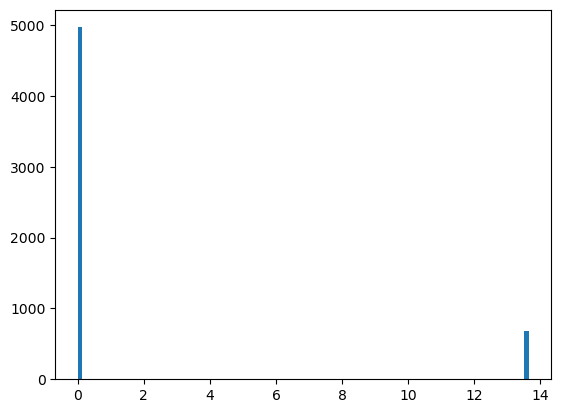

In [435]:
# plot the distribution of weights
import matplotlib.pyplot as plt
plt.hist(weights_sorted, bins=100)

In [436]:
def w(x, y, eps_s, eps_r):
    matching_pairs = []
    for n in range(len(train_diff_rewards)):
        i2, diff2 = train_diff_rewards[n]
        if np.linalg.norm(x - true_b_states_train[i2][0]) < eps_s and \
            abs(y - diff2) < eps_r:
            matching_pairs.append(n)
    log_w = 0
    n = len(matching_pairs)
    for n1 in matching_pairs:
        i2, diff2 = train_diff_rewards[n1]
        log_w1 = 0
        # for t in range(len(true_b_actions_train[i])):
        #     log_rho_e = target_policy.log_prob(true_b_states_train[i][t], true_b_actions_train[i][t])
        #     log_rho_b = behavior_policy.log_prob(true_b_states_train[i][t], true_b_actions_train[i][t])
        #     log_rho = log_rho_e - log_rho_b
        #     log_rho_e_gen = target_policy.log_prob(cp_trajs_states_train[i][t], cp_trajs_actions_train[i][t])
        #     log_rho_b_gen = behavior_policy.log_prob(cp_trajs_states_train[i][t], cp_trajs_actions_train[i][t])
        #     log_rho_gen = log_rho_e_gen - log_rho_b_gen
        #     log_w1 += log_rho
        #     log_w1 += log_rho_gen
        log_w1 = log_w_double[i2]
        log_w += log_w1
        clip_log_w = np.clip(log_w1, a_min=-10, a_max=10)
        w = np.exp(clip_log_w)
    if n > 0:
        return w/n
    else:
        return -1
    
start_s = true_b_states_train[0][0]
y_list = np.linspace(-1000, 1000, 1000)
CP_s_y = []
for y in y_list:
    w_ = w(start_s, y, eps_s, eps_r)
    if w_ != -1:
        new_weights = np.append(weights_sorted, w_)
        normalized_weights = new_weights / np.sum(new_weights)
        
        low_level = 0
        high_level = 0
        low_q = 0
        high_q = 0
        for i in range(len(delta_reward_sorted)):
            low_level += normalized_weights[i]
            if low_level >= alpha/2:
                low_q = delta_reward_sorted[i-1]
                break
        for i in range(len(delta_reward_sorted)):
            high_level += normalized_weights[i]
            if high_level >= 1 - alpha/2:
                high_q = delta_reward_sorted[i-1]
                break
        print("y: ", y, "low_q: ", low_q, "high_q: ", high_q)
        break
        # if low_q <= y <= high_q:
        #     CP_1_y.append(y)

y:  -601.6016016016015 low_q:  570.3847 high_q:  610.4392


In [437]:
cp_ppi_b = pickle.load(open("./saved_trajectories/first_term_cp_ppi.pkl", "rb"))
first_term_cp_ppi = np.mean(cp_ppi_b['ep_returns'])

CP = (first_term_cp_ppi + low_q, first_term_cp_ppi + high_q)
print("first_term_cp_ppi: ", first_term_cp_ppi)
print("CP: ", CP)

first_term_cp_ppi:  1393.9787232806361
CP:  (np.float64(1964.3634278704799), np.float64(2004.4179322650111))


In [438]:
len(true_b_actions_train)

5650